In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import textwrap

In [2]:
#pwd
path = '/Users/eimonsoe/Documents/Final Year (Second Semester)/Senior Capstone II/SeniorCapstone/Survey_Dataset_Ei Mon Soe.csv'
df = pd.read_csv(path)
print("File loaded successfully!")

File loaded successfully!


In [3]:
df.head()

,Timestamp,Do you agree to participate in this survey?,1. Your Location,2. Your Region/State,3. What is your age group?,4. What is your approximate monthly household income?(MMK),5. What is the highest level of education you have completed?,6. How often do you use single-use plastic items in your weekly life?,7.Which of the following single-use plastic items do you usually use in your weekly life?,8. Where do you usually get your single-use plastic from?,...,13. What do you think happens to the plastic you throw in the bin in your region?,14. How aware are you that plastic production and disposal contributes to climate change?,15. Do you believe current plastic usage in Myanmar is contributing to climate change?,16. When do you think the effects of today’s plastic usage on climate change will become noticeable?,17. Would you support reducing single-use plastics or replacing them with alternatives?,18. Do you think that plastic waste is burned?,19. What percentage of plastic waste do you think is burned?,20. Do you think that plastic waste usually ends up in a landfill site?,21. What percentage of plastic waste ends up in a landfill or dumping ground?,22. How do you think plastic waste in landfills and open burning affects climate change?
0,1/4/2026 22:42:02,Yes,Rural,Sagaing,18-25,"Less than 300,000",University/College,6-10,"Plastic bags, Plastic straws","Local markets, Coffee/tea shops",...,Burned,Somewhat aware,Yes,Already visible now,Support,No,NaN,Yes,Not sure,Release GHG
1,1/4/2026 22:47:56,Yes,Rural,Sagaing,18-25,"300,000-600,000",High school,3-5,"Plastic bags, Food sachets","Local markets, Street Vendors, Coffee/tea shops",...,Burned,Somewhat aware,Yes,Already visible now,Support,No,Not applicable,No,Not sure,Release GHG
2,1/4/2026 22:49:01,Yes,Urban,Yangon,18-25,"300,000-600,000",University/College,More than 10,"Plastic bags, Bottled water, Plastic container...","Supermarkets, Local markets, Street Vendors, F...",...,Ends up in landfills,Somewhat aware,Yes,Already visible now,Support,No,Not applicable,Yes,51%-75%,Increases the Earth’s temperature
3,1/6/2026 21:59:12,Yes,Urban,Yangon,18-25,No income,University/College,More than 10,"Plastic bags, Plastic straws","Supermarkets, Local markets, Street Vendors, F...",...,Recycled,Very aware,Yes,Already visible now,Strongly support,No,Less than half (1%-25%),Yes,More than 75%,Release GHG
4,1/8/2026 23:09:47,Yes,Urban,Yangon,18-25,"300,000-600,000",High school,6-10,"Plastic bags, Plastic containers","Supermarkets, Food Delivery, Online Delivery",...,Ends up in landfills,Very aware,Yes,Already visible now,Strongly support,No,More than half (51%-75%),No,25%-50%,Pollutes soil/water


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 24 columns):
 #   Column                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                --------------  ----- 
 0   Timestamp                                                                                             304 non-null    object
 1   Do you agree to participate in this survey?                                                           304 non-null    object
 2   1. Your Location                                                                                      296 non-null    object
 3   2. Your Region/State                                                                                  302 non-null    object
 4   3. What is your age group?                                                                            303 non-

In [5]:
#Drop first two columns which are timestamp, and agreement and are not related with analysis. 
df=df.drop(df.columns[[0,1]], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 22 columns):
 #   Column                                                                                                Non-Null Count  Dtype 
---  ------                                                                                                --------------  ----- 
 0   1. Your Location                                                                                      296 non-null    object
 1   2. Your Region/State                                                                                  302 non-null    object
 2   3. What is your age group?                                                                            303 non-null    object
 3   4. What is your approximate monthly household income?(MMK)                                            303 non-null    object
 4   5. What is the highest level of education you have completed?                                         301 non-

In [6]:
df.isna().sum()

1. Your Location                                                                                        8
2. Your Region/State                                                                                    2
3. What is your age group?                                                                              1
4. What is your approximate monthly household income?(MMK)                                              1
5. What is the highest level of education you have completed?                                           3
6. How often do you use single-use plastic items in your weekly life?                                   2
7.Which of the following single-use plastic items do you usually use in your weekly life?               2
8. Where do you usually get your single-use plastic from?                                               3
9. How many plastic bags do you usually get from shops or markets in your weekly life?                  2
10. When buying street food or market food, ho

In [7]:
#Rename Columns
rename_cols = {
    '1. Your Location': 'Location',
    '2. Your Region/State': 'Region',
    '3. What is your age group?': 'Age_Group',
    '4. What is your approximate monthly household income?(MMK)': 'Monthly_Income',
    '5. What is the highest level of education you have completed?': 'Education_Level',
    '6. How often do you use single-use plastic items in your weekly life?': 'Usage_of_Items',
    '7.Which of the following single-use plastic items do you usually use in your weekly life?': 'SUP_Items',
    '8. Where do you usually get your single-use plastic from?': 'Sources',
    '9. How many plastic bags do you usually get from shops or markets in your weekly life?': 'Plastic_Bags',
    '10. When buying street food or market food, how often does it come in plastic?': 'Street_Food_Plastic',
    '11. Compared to what you see outside (litter, packaging, shops), do you think you personally use:': 'Personal_Use',
    '12. What do you often do with your plastic waste after you use the product?': 'After_Use',
    '13. What do you think happens to the plastic you throw in the bin in your region?': 'Plastic_Fate',
    '14. How aware are you that plastic production and disposal contributes to climate change?': 'Awareness',
    '15. Do you believe current plastic usage in Myanmar is contributing to climate change?': 'Plastics_Impact',
    '16. When do you think the effects of today’s plastic usage on climate change will become noticeable?': 'Impact_Timeline',
    '17. Would you support reducing single-use plastics or replacing them with alternatives?': 'Support_Reduction',
    '18. Do you think that plastic waste is burned?': 'Burn_Waste',
    '19. What percentage of plastic waste do you think is burned?': 'Burn_Percentage',
    '20. Do you think that plastic waste usually ends up in a landfill site?': 'Landfill_Waste',
    '21. What percentage of plastic waste ends up in a landfill or dumping ground?': 'Landfill_Percentage',
    '22. How do you think plastic waste in landfills and open burning affects climate change?': 'Climate_Effect'
}
df.rename(columns=rename_cols, inplace=True)
df.head()

,Location,Region,Age_Group,Monthly_Income,Education_Level,Usage_of_Items,SUP_Items,Sources,Plastic_Bags,Street_Food_Plastic,...,Plastic_Fate,Awareness,Plastics_Impact,Impact_Timeline,Support_Reduction,Burn_Waste,Burn_Percentage,Landfill_Waste,Landfill_Percentage,Climate_Effect
0,Rural,Sagaing,18-25,"Less than 300,000",University/College,6-10,"Plastic bags, Plastic straws","Local markets, Coffee/tea shops",6-10,Always,...,Burned,Somewhat aware,Yes,Already visible now,Support,No,NaN,Yes,Not sure,Release GHG
1,Rural,Sagaing,18-25,"300,000-600,000",High school,3-5,"Plastic bags, Food sachets","Local markets, Street Vendors, Coffee/tea shops",6-10,Always,...,Burned,Somewhat aware,Yes,Already visible now,Support,No,Not applicable,No,Not sure,Release GHG
2,Urban,Yangon,18-25,"300,000-600,000",University/College,More than 10,"Plastic bags, Bottled water, Plastic container...","Supermarkets, Local markets, Street Vendors, F...",6-10,Sometimes,...,Ends up in landfills,Somewhat aware,Yes,Already visible now,Support,No,Not applicable,Yes,51%-75%,Increases the Earth’s temperature
3,Urban,Yangon,18-25,No income,University/College,More than 10,"Plastic bags, Plastic straws","Supermarkets, Local markets, Street Vendors, F...",More than 10,Always,...,Recycled,Very aware,Yes,Already visible now,Strongly support,No,Less than half (1%-25%),Yes,More than 75%,Release GHG
4,Urban,Yangon,18-25,"300,000-600,000",High school,6-10,"Plastic bags, Plastic containers","Supermarkets, Food Delivery, Online Delivery",3-5,Always,...,Ends up in landfills,Very aware,Yes,Already visible now,Strongly support,No,More than half (51%-75%),No,25%-50%,Pollutes soil/water


In [8]:
#Create a list of all my column names
columns_to_fix = [
    'Location', 'Region', 'Age_Group', 'Monthly_Income', 'Education_Level', 
    'Usage_of_Items', 'SUP_Items', 'Sources', 'Plastic_Bags', 'Street_Food_Plastic', 
    'Personal_Use', 'After_Use', 'Plastic_Fate', 'Awareness', 'Plastics_Impact', 
    'Impact_Timeline', 'Support_Reduction', 'Burn_Waste', 'Burn_Percentage', 
    'Landfill_Waste', 'Landfill_Percentage', 'Climate_Effect'
]
for col in columns_to_fix: #Fill missing values with mode as they all are categorical data. 
    if col in df.columns:
        most_frequent = df[col].mode()[0] #.mode()[0] gets the most frequent string in that column
        df[col] = df[col].fillna(most_frequent)
print(df[columns_to_fix].isnull().sum())

Location               0
Region                 0
Age_Group              0
Monthly_Income         0
Education_Level        0
Usage_of_Items         0
SUP_Items              0
Sources                0
Plastic_Bags           0
Street_Food_Plastic    0
Personal_Use           0
After_Use              0
Plastic_Fate           0
Awareness              0
Plastics_Impact        0
Impact_Timeline        0
Support_Reduction      0
Burn_Waste             0
Burn_Percentage        0
Landfill_Waste         0
Landfill_Percentage    0
Climate_Effect         0
dtype: int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Location             304 non-null    object
 1   Region               304 non-null    object
 2   Age_Group            304 non-null    object
 3   Monthly_Income       304 non-null    object
 4   Education_Level      304 non-null    object
 5   Usage_of_Items       304 non-null    object
 6   SUP_Items            304 non-null    object
 7   Sources              304 non-null    object
 8   Plastic_Bags         304 non-null    object
 9   Street_Food_Plastic  304 non-null    object
 10  Personal_Use         304 non-null    object
 11  After_Use            304 non-null    object
 12  Plastic_Fate         304 non-null    object
 13  Awareness            304 non-null    object
 14  Plastics_Impact      304 non-null    object
 15  Impact_Timeline      304 non-null    object
 16  Support_

# Univariate & Bivariate Analysis

In [10]:
#1.Lists all unique regions and how many people responded from each
region_summary = df['Region'].value_counts()
print("--- Survey Responses by Region ---")
print(region_summary)

--- Survey Responses by Region ---
Region
Yangon         88
Rakhine        60
Mandalay       27
Sagaing        26
Shan           20
Bago           14
Ayeyarwady     13
Magway         12
Mon            11
Kayin           9
Kachin          7
Tanintharyi     6
Kayah           6
Chin            5
Name: count, dtype: int64


In [11]:
import geopandas as gpd
import pandas as pd

# 1. Load your shapefile
world = gpd.read_file('myanmar_regions.shp')

# 2. Your survey data
data = {
    'Region': ['Yangon', 'Rakhine', 'Mandalay', 'Sagaing', 'Shan', 'Bago', 'Ayeyarwady', 'Magway', 'Mon', 'Kayin', 'Kachin','Tanintharyi', 'Kayah','Chin'],
    'Survey_Count': [88, 60, 27, 26, 20, 14, 13, 12, 11, 9, 7, 6, 6, 5]
}
df_survey = pd.DataFrame(data)

# 3. Clean and Merge
world['ST_CLEAN'] = world['ST'].astype(str).str.strip()
df_survey['REG_CLEAN'] = df_survey['Region'].astype(str).str.strip()
merged = world.merge(df_survey, left_on='ST_CLEAN', right_on='REG_CLEAN', how='left')
merged['Survey_Count'] = merged['Survey_Count'].fillna(0)

# --- THE FIX STARTS HERE ---
# If your shapefile doesn't have a CRS, set it to 4326 (WGS84)
if merged.crs is None:
    merged.set_crs(epsg=4326, inplace=True)
else:
    # Ensure it's converted to the format web browsers expect
    merged = merged.to_crs(epsg=4326)
# --- THE FIX ENDS HERE ---

# 4. Save to JSON
merged.to_file("myanmar.json", driver='GeoJSON')
print("Successfully exported myanmar.json with CRS!")

Successfully exported myanmar.json with CRS!


Successfully matched 14 regions.


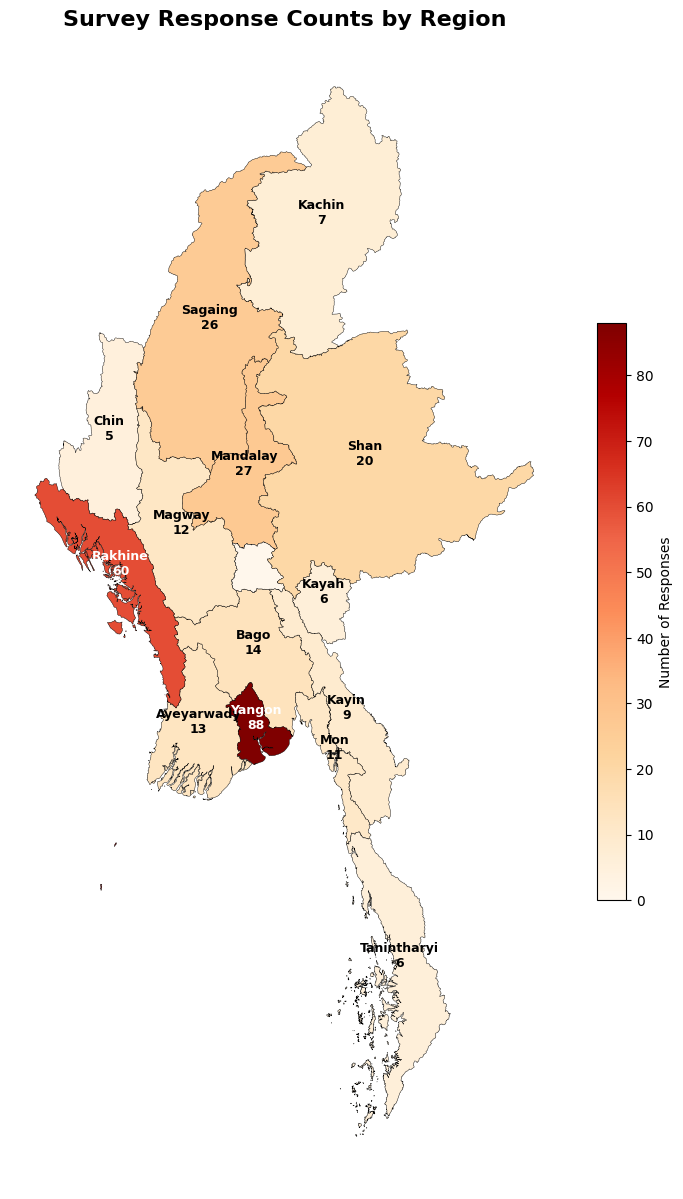

In [11]:
world = gpd.read_file('myanmar_regions.shp') #Load the shapefile from my directory. 
data = {
    'Region': ['Yangon', 'Rakhine', 'Mandalay', 'Sagaing', 'Shan', 'Bago', 'Ayeyarwady', 'Magway', 'Mon', 'Kayin', 'Kachin','Tanintharyi', 'Kayah','Chin'],
    'Survey_Count': [88, 60, 27, 26, 20, 14, 13, 12, 11, 9, 7, 6, 6, 5]
}
df_survey = pd.DataFrame(data) #My survey data
world['ST_CLEAN'] = world['ST'].astype(str).str.strip() #Strip spaces and force everything to string type cus there was an error in spelling in my first test.
df_survey['REG_CLEAN'] = df_survey['Region'].astype(str).str.strip()
merged = world.merge(df_survey, left_on='ST_CLEAN', right_on='REG_CLEAN', how='left') #Using 'inner' first to verify matches, then switching to 'left' for the map.
merged['Survey_Count'] = merged['Survey_Count'].fillna(0)
matches = merged[merged['Survey_Count'] > 0] #Verify (This should now show 14 matches)
print(f"Successfully matched {len(matches)} regions.")

fig, ax = plt.subplots(1, 1, figsize=(10, 15))
merged.plot(column='Survey_Count', 
            cmap='OrRd', 
            legend=True, 
            ax=ax, 
            edgecolor='black', 
            linewidth=0.3,
            legend_kwds={'label': "Number of Responses", 'shrink': 0.5})
#Loop through the matched regions to add labels
for idx, row in matches.iterrows():
    centroid = row.geometry.centroid
    text_color = 'white' if row['Survey_Count'] >= 50 else 'black'
    ax.text(centroid.x, centroid.y, 
            f"{row['ST']}\n{int(row['Survey_Count'])}", 
            fontsize=9, 
            ha='center', 
            fontweight='bold',
            color=text_color) #Applies the dynamic color 
plt.title('Survey Response Counts by Region', fontsize=16, fontweight='bold')
ax.axis('off')
plt.show()

In [12]:
#1.Define the logical order
age_order = ['18-25', '26-35', '36-50', 'Over 50']

#2.Convert to Categorical type (this prevents alphabetical sorting)
df['Age_Group'] = pd.Categorical(df['Age_Group'], categories=age_order, ordered=True)

#3.Define orders for the variables we will compare Age against
awareness_order = ['Very aware', 'Somewhat aware', 'Neutral', 'Slightly aware', 'Not aware']
usage_order = ['0', '1-2', '3-5', '6-10', 'More than 10']

df['Usage_of_Items'] = pd.Categorical(df['Usage_of_Items'], categories=usage_order, ordered=True)
df['Awareness'] = pd.Categorical(df['Awareness'], categories=awareness_order, ordered=True)

In [13]:
cols_to_clean = ['Age_Group', 'Usage_of_Items', 'Awareness'] #Remove hidden spaces from my data first
for col in cols_to_clean:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
age_order = ['18-25', '26-35', '36-50', 'Over 50']
awareness_order = ['Not aware', 'Slightly aware', 'Neutral', 'Somewhat aware', 'Very aware']
usage_order = ['0', '1-2', '3-5', '6-10', 'More than 10']
df['Age_Group'] = pd.Categorical(df['Age_Group'], categories=age_order, ordered=True)
df['Usage_of_Items'] = pd.Categorical(df['Usage_of_Items'], categories=usage_order, ordered=True)
df['Awareness'] = pd.Categorical(df['Awareness'], categories=awareness_order, ordered=True)

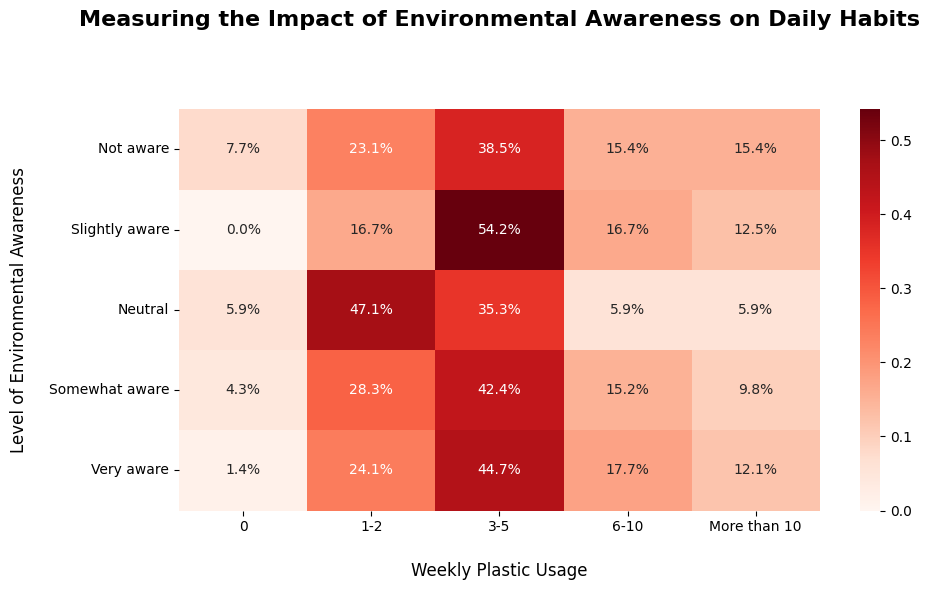

In [14]:
#2.The Awareness-Behavior Gap
#Does high awareness (Q14) lead to lower plastic usage (Q6)?
plt.figure(figsize=(10, 6))
#Normalizing by index shows the distribution of usage within each awareness level
gap_analysis = pd.crosstab(df['Awareness'], df['Usage_of_Items'], normalize='index')
sns.heatmap(gap_analysis, annot=True, cmap='Reds', fmt='.1%')
plt.title('Measuring the Impact of Environmental Awareness on Daily Habits', fontsize=16, fontweight='bold', pad=60, loc='center')
plt.xlabel('Weekly Plastic Usage', fontsize=12, labelpad=20)
plt.ylabel('Level of Environmental Awareness', fontsize=12, labelpad=15)     
plt.tight_layout()
plt.show()

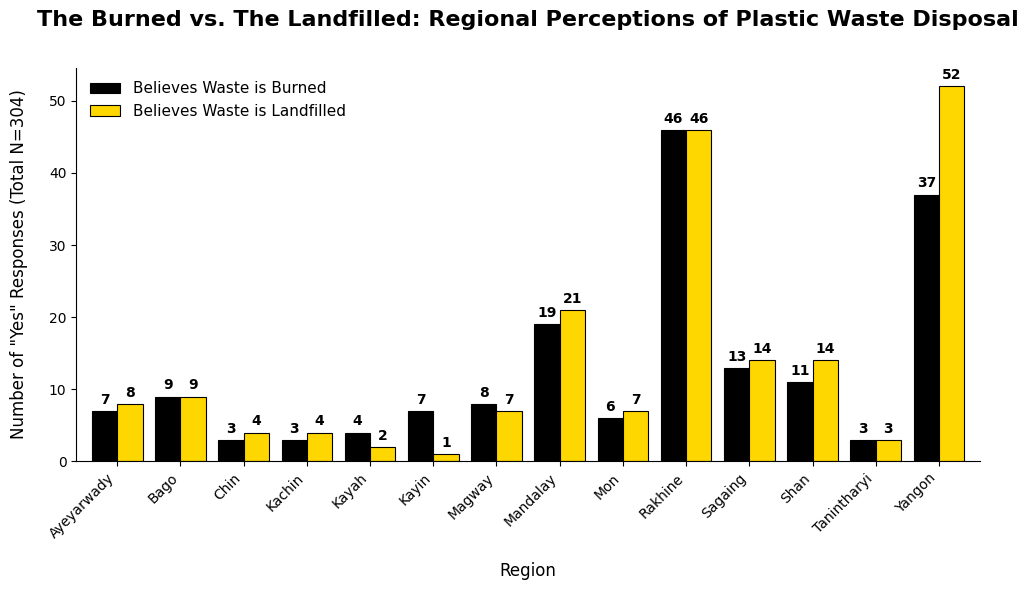

In [15]:
#3.Regional Waste Fate Perceptions
#Burning (Q18) and Landfilling (Q20) across Regions.
#Calculate % of 'Yes' for both burning and landfill per region
#1.Group by Region and calculate the exact count of 'Yes' responses for both questions
fate_comparison = df.groupby('Region').agg({
    'Burn_Waste': lambda x: (x == 'Yes').sum(),
    'Landfill_Waste': lambda x: (x == 'Yes').sum()
}).reset_index()

#2.Plotting the grouped bar chart
custom_palette = ['black', '#FFD700'] 
ax = fate_comparison.plot(
    x='Region', 
    kind='bar', 
    figsize=(10, 6), 
    color=custom_palette,
    edgecolor='black',
    linewidth=0.8,
    width=0.8
)

#3.Add the exact data labels (counts) on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10, fontweight='bold')

#4.Chart styling and titles (Legend moved to upper left)
plt.title('The Burned vs. The Landfilled: Regional Perceptions of Plastic Waste Disposal', fontsize=16, fontweight='bold', pad=30) 
plt.ylabel('Number of "Yes" Responses (Total N=304)', fontsize=12, labelpad=15)
plt.xlabel('Region', fontsize=12, labelpad=15)
plt.legend(['Believes Waste is Burned', 'Believes Waste is Landfilled'], loc='upper left', frameon=False, fontsize=11) # Changed to upper left
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

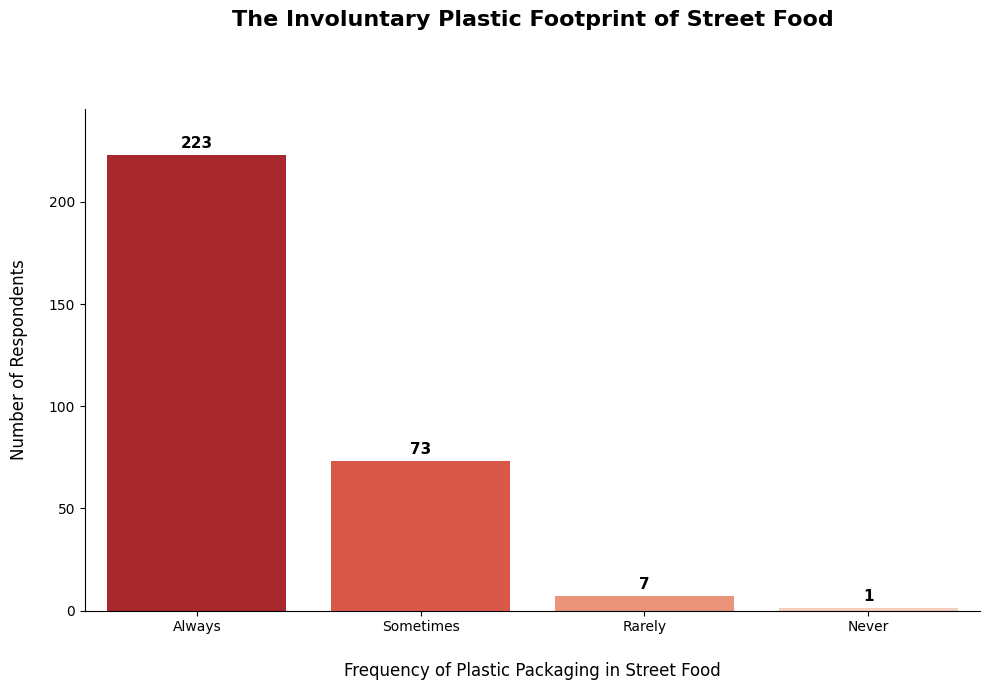

In [16]:
#4.The Street Food Trap
#How much of high usage is driven by Street Food (Q10) and (Q6)?
plt.figure(figsize=(10, 7))
ax = sns.countplot(
    data=df, 
    x='Street_Food_Plastic', 
    hue='Street_Food_Plastic', 
    palette='Reds_r', 
    legend=False
)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11, fontweight='bold')
plt.title('The Involuntary Plastic Footprint of Street Food', fontsize=16, fontweight='bold', pad=60, loc='center')
plt.xlabel('Frequency of Plastic Packaging in Street Food', fontsize=12, labelpad=20)
plt.ylabel('Number of Respondents', fontsize=12, labelpad=15)
plt.ylim(0, df['Street_Food_Plastic'].value_counts().max() * 1.1)
sns.despine()
plt.xticks(rotation=0) 
plt.tight_layout()
plt.show()

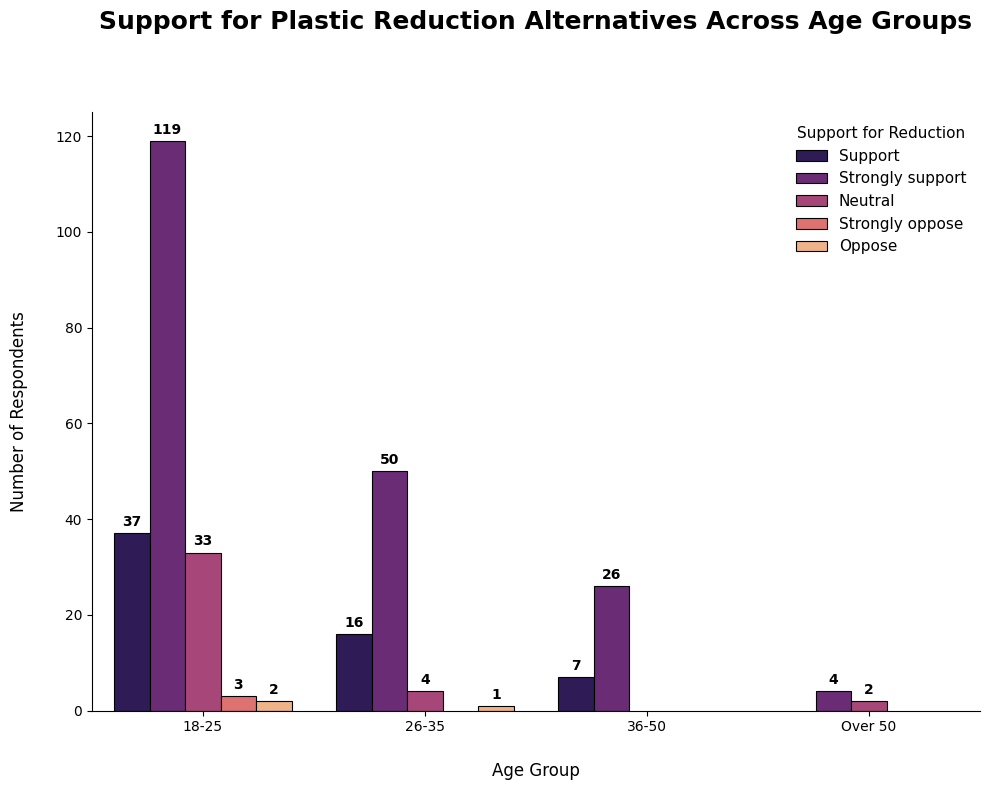

In [17]:
#5.Generational Support for Change
#Age (Q3) vs. Support for Alternatives (Q17).
plt.figure(figsize=(10, 8))
ax = sns.countplot(data=df, x='Age_Group', hue='Support_Reduction', palette='magma', edgecolor='black',linewidth=0.8)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')
plt.title('Support for Plastic Reduction Alternatives Across Age Groups', fontsize=18, fontweight='bold', pad=60, loc='center')
plt.ylabel('Number of Respondents', fontsize=12, labelpad=20)
plt.xlabel('Age Group', fontsize=12, labelpad=20)
plt.legend(title='Support for Reduction',loc='upper right', frameon=False, fontsize=11, title_fontsize=11)
sns.despine() 
plt.tight_layout()
plt.show()

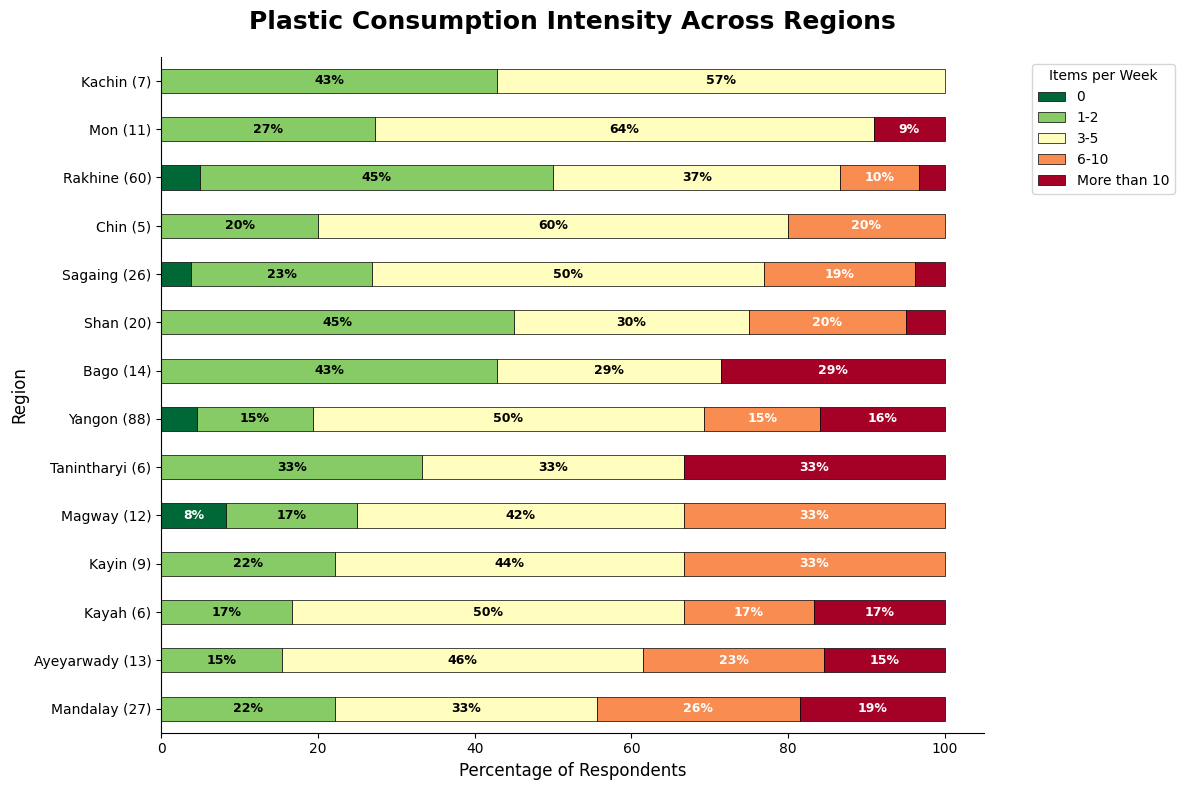

<Figure size 640x480 with 0 Axes>

In [19]:
#6.Plastic Consumption Intensity Across Regions
#Question 2 and 6
usage_order = ['0', '1-2', '3-5', '6-10', 'More than 10']
df['Usage_of_Items'] = pd.Categorical(df['Usage_of_Items'], categories=usage_order, ordered=True)

#Create a Crosstab (Region vs Usage) and Normalize (to get percentages per region)
region_usage = pd.crosstab(df['Region'], df['Usage_of_Items'], normalize='index') * 100

#Sort regions by the combined '6-10' and 'More than 10' usage (The "Heavy Users")
region_usage['Heavy_Total'] = region_usage['6-10'] + region_usage['More than 10']
region_usage_sorted = region_usage.sort_values(by='Heavy_Total', ascending=False).drop(columns='Heavy_Total')

#Create a mapping of Region name to its count
counts = df['Region'].value_counts()
new_labels = {reg: f"{reg} ({counts[reg]})" for reg in region_usage_sorted.index}

#Rename the index of your plotted dataframe
region_usage_sorted = region_usage_sorted.rename(index=new_labels)
ax = region_usage_sorted.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 8), 
    colormap='RdYlGn_r', #Red for high use, Green for low use
    edgecolor='black',
    linewidth=0.5)

plt.title('Plastic Consumption Intensity Across Regions', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Percentage of Respondents', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.legend(title='Items per Week', bbox_to_anchor=(1.05, 1), loc='upper left')

for n, x in enumerate([*region_usage_sorted.index.values]):
    for i, (proportion, y_loc) in enumerate(zip(region_usage_sorted.loc[x], region_usage_sorted.loc[x].cumsum())): #Iterate through each usage category for that region                             
        if proportion > 5: #Only label if the segment is big enough
            if i in [1, 2]:  #Index 2 is '3-5' (Yellow). Index 1 is '1-2' (Light Green/Yellow).
                text_color = 'black'
            else:
                text_color = 'white'
            plt.text(y_loc - proportion / 2, n, 
                     f'{proportion:.0f}%', 
                     va='center', ha='center', 
                     color=text_color, # Applied dynamic color here
                     fontsize=9, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()
sns.despine()
plt.tight_layout()
plt.show()

In [25]:
#Get exact counts for perception gap chart (Website)
perception_counts = pd.crosstab(df['Personal_Use'], df['Plastic_Bags'])
print(perception_counts)

Plastic_Bags                   0  1-2  3-5  6-10  More than 10
Personal_Use                                                  
A little more                  2   37   15     7             6
About the same                 3   28   36    22            11
Less than others               3   20   26    12             9
Much less than others          2   13   10     8             1
Much more plastic than others  1    9   12     8             3


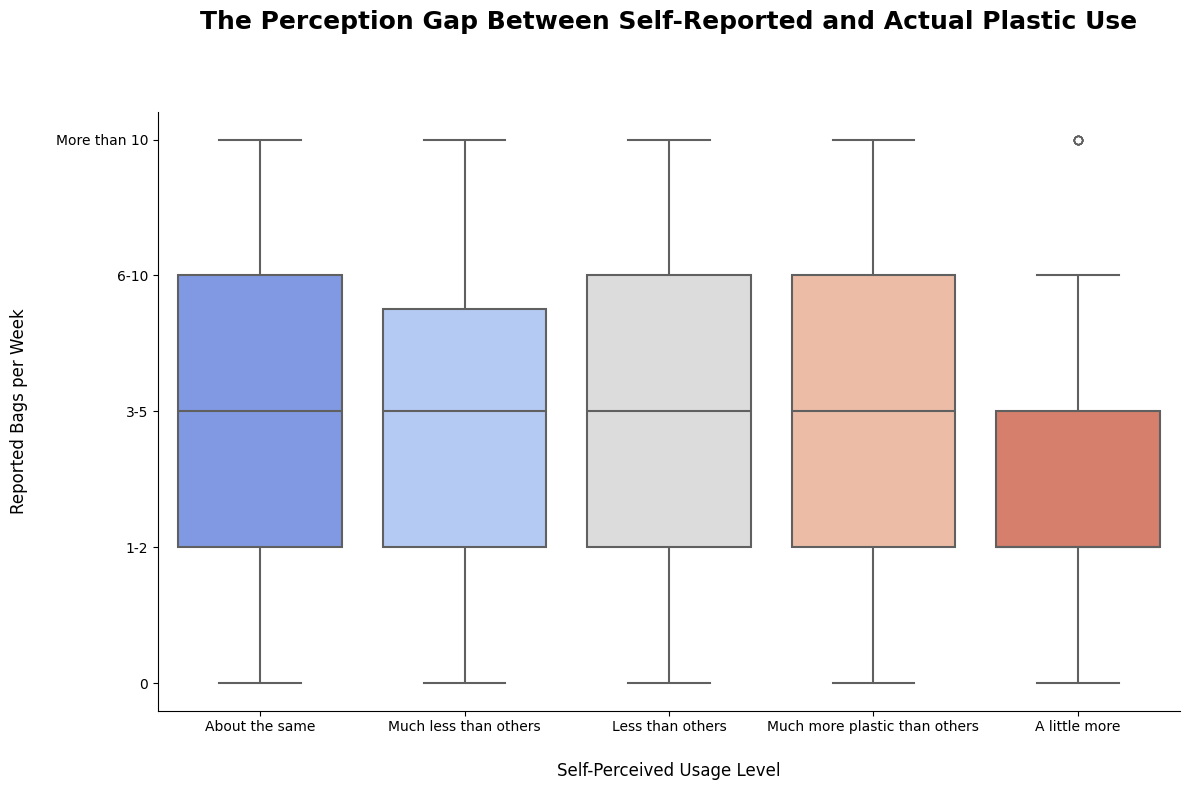

In [20]:
#7.Personal Bias Check
#Self-assessment (Q11) vs. Reported Bag Count (Q9).
plt.figure(figsize=(12, 8))
df['Plastic_Bags'] = pd.Categorical(df['Plastic_Bags'], categories=usage_order, ordered=True)
sns.boxplot(data=df, x='Personal_Use', y=df['Plastic_Bags'].cat.codes, hue='Personal_Use', palette='coolwarm', legend=False, linewidth=1.5)
plt.title('The Perception Gap Between Self-Reported and Actual Plastic Use', fontsize=18,fontweight='bold', pad=60, loc='center')
plt.xlabel('Self-Perceived Usage Level', fontsize=12, labelpad=20)
plt.ylabel('Reported Bags per Week', fontsize=12, labelpad=20)
plt.yticks(range(len(usage_order)), usage_order) 
sns.despine()
plt.tight_layout()
plt.show()

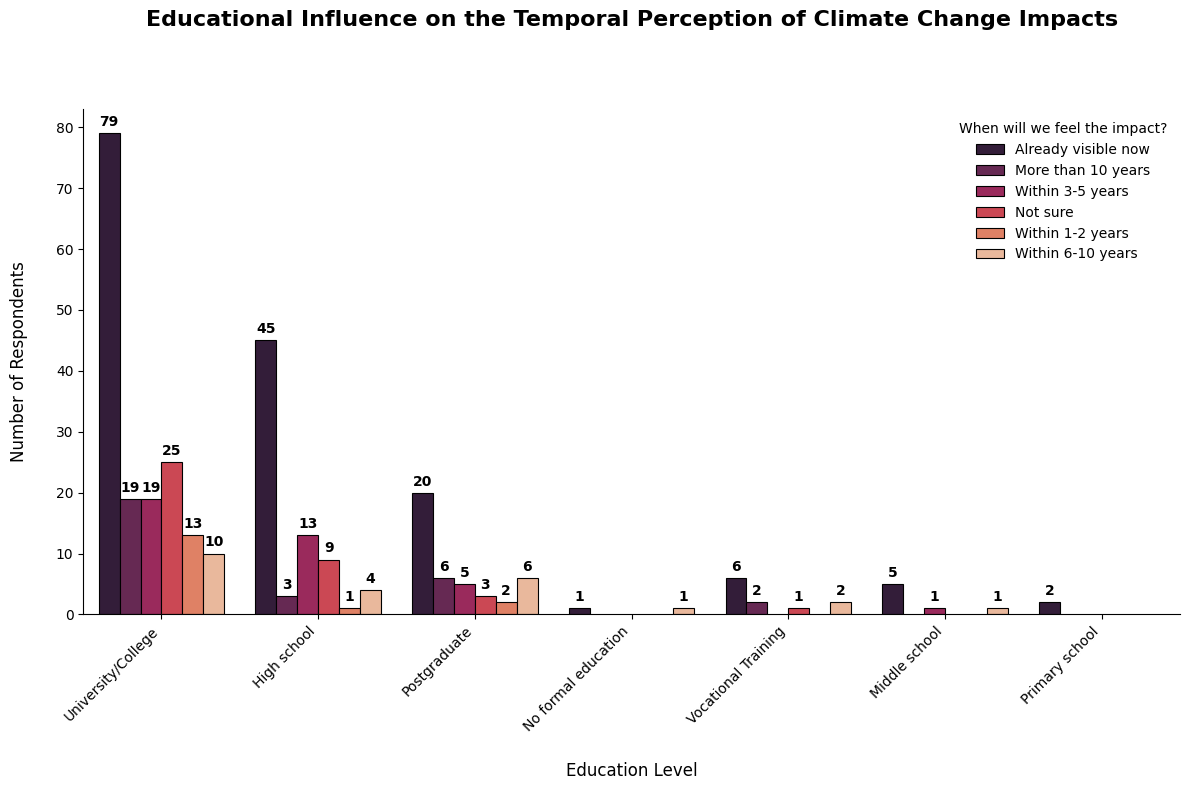

In [ ]:
#8.Education vs. Impact  (For Website)
#Education Level (Q5) vs. When effects will be noticed (Q16).
plt.figure(figsize=(12, 8))
ax = sns.countplot(data=df, x='Education_Level', hue='Impact_Timeline', palette='rocket', edgecolor='black', linewidth=0.8)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.title('Educational Influence on the Temporal Perception of Climate Change Impacts', fontsize=16, fontweight='bold', pad=60, loc='center')
plt.xlabel('Education Level', fontsize=12, labelpad=20)
plt.ylabel('Number of Respondents', fontsize=12, labelpad=20)
plt.legend(title='When will we feel the impact?', 
           loc='upper right', 
           frameon=False, 
           fontsize=10)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

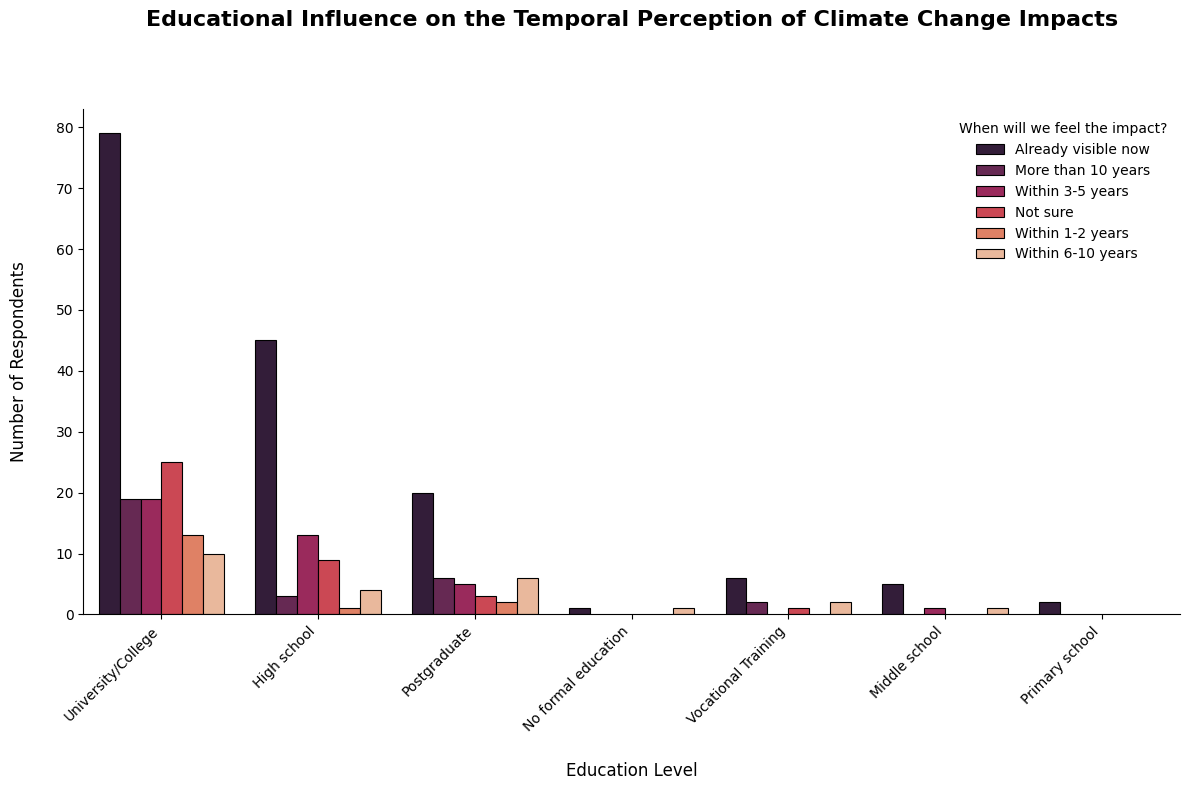

In [67]:
#8.Education vs. Impact Timeline
#Education Level (Q5) vs. When effects will be noticed (Q16).
plt.figure(figsize=(12, 8))
sns.countplot(data=df, x='Education_Level', hue='Impact_Timeline', palette='rocket', edgecolor='black', linewidth=0.8)
plt.title('Educational Influence on the Temporal Perception of Climate Change Impacts', fontsize=16, fontweight='bold', pad=60, loc='center')
plt.xlabel('Education Level', fontsize=12, labelpad=20)
plt.ylabel('Number of Respondents', fontsize=12, labelpad=20)
plt.legend(title='When will we feel the impact?', 
           loc='upper right', 
           frameon=False, 
           fontsize=10)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

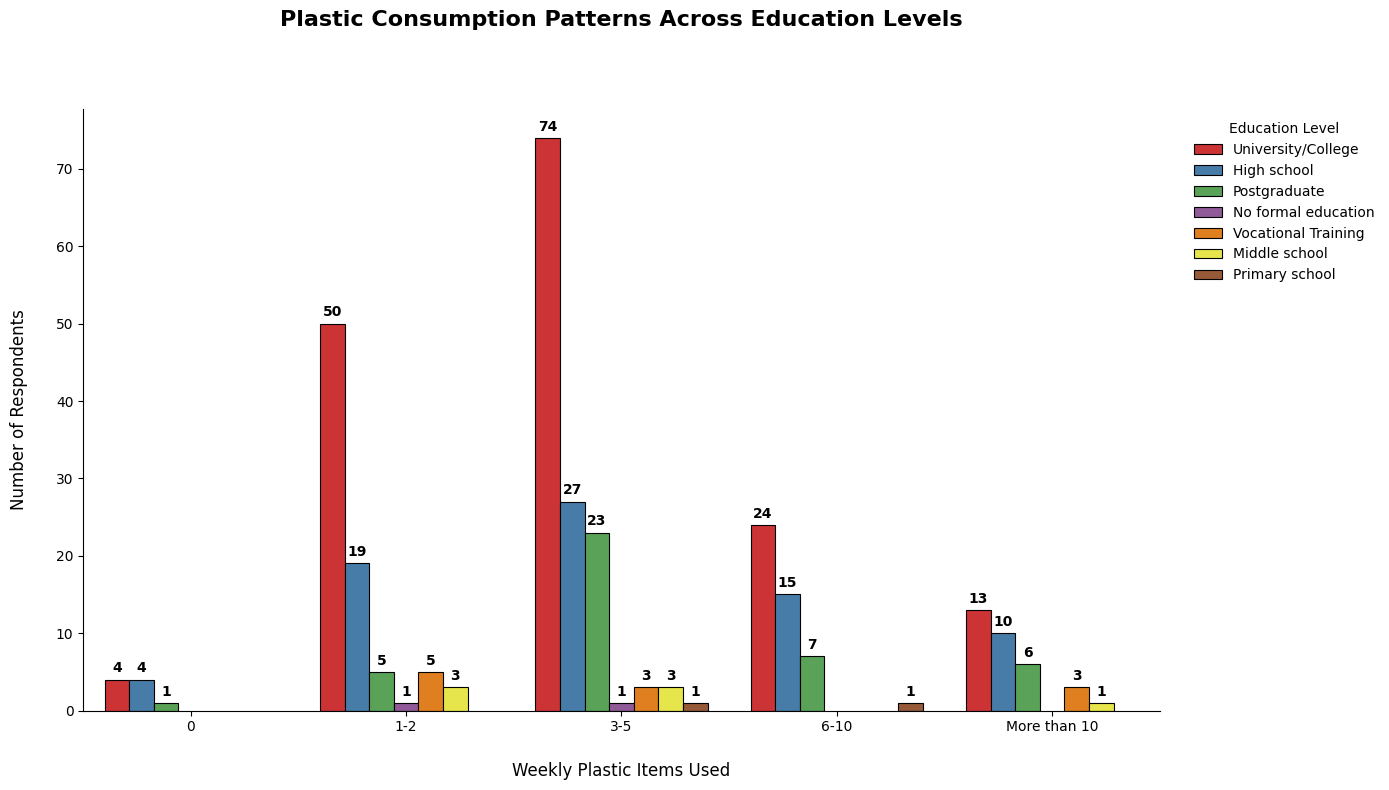

In [22]:
#9.Education Level vs. Weekly Usage (High-Contrast Version) (Website)
plt.figure(figsize=(14, 8))
ax = sns.countplot(data=df, x='Usage_of_Items', hue='Education_Level', palette='Set1', edgecolor='black', linewidth=0.8)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.title('Plastic Consumption Patterns Across Education Levels', fontsize=16, fontweight='bold', pad=60, loc='center')
plt.xlabel('Weekly Plastic Items Used', fontsize=12, labelpad=20)
plt.ylabel('Number of Respondents', fontsize=12, labelpad=20)
plt.legend(title='Education Level', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

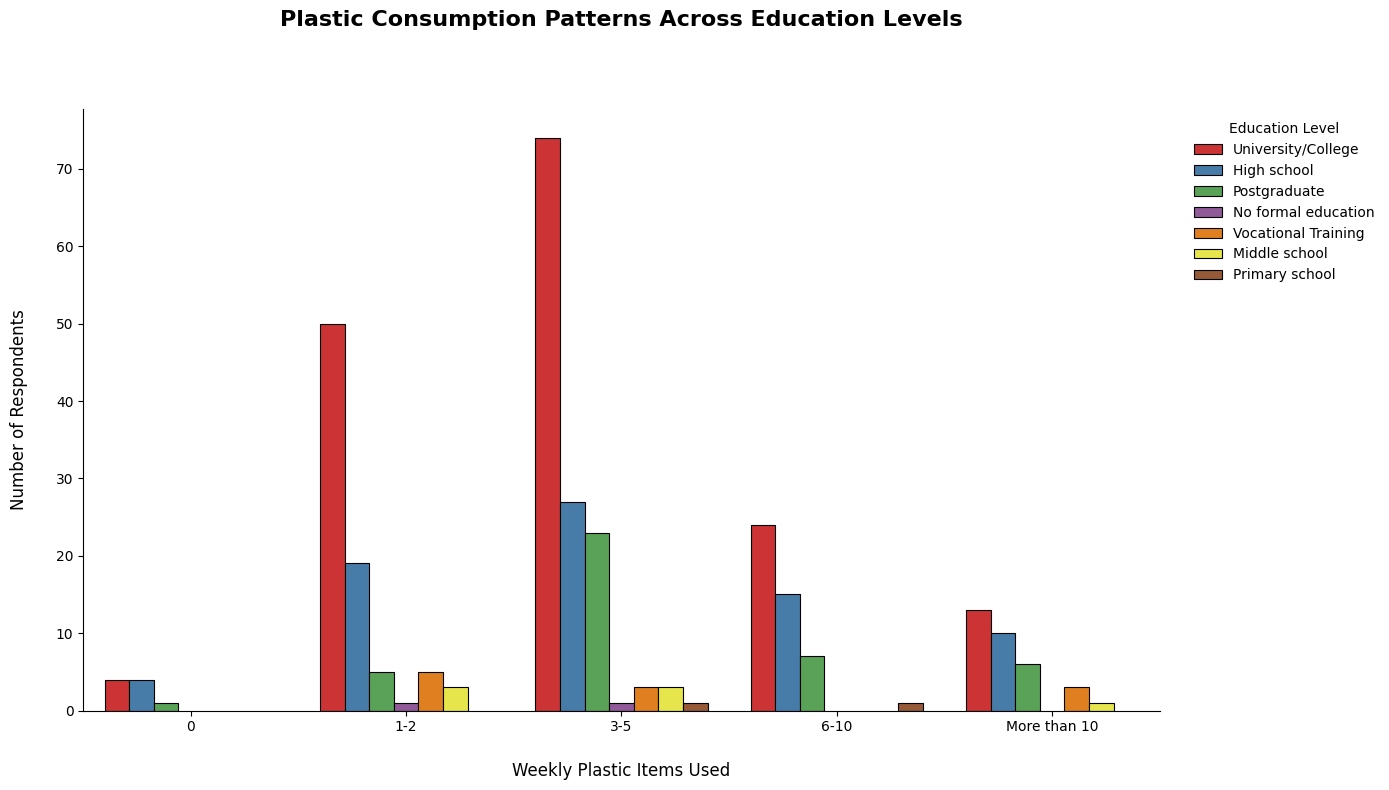

In [68]:
#9.Education Level vs. Weekly Usage (High-Contrast Version)
plt.figure(figsize=(14, 8))
sns.countplot(data=df, x='Usage_of_Items', hue='Education_Level', palette='Set1', edgecolor='black', linewidth=0.8)
plt.title('Plastic Consumption Patterns Across Education Levels', fontsize=16, fontweight='bold', pad=60, loc='center')
plt.xlabel('Weekly Plastic Items Used', fontsize=12, labelpad=20)
plt.ylabel('Number of Respondents', fontsize=12, labelpad=20)
plt.legend(title='Education Level', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

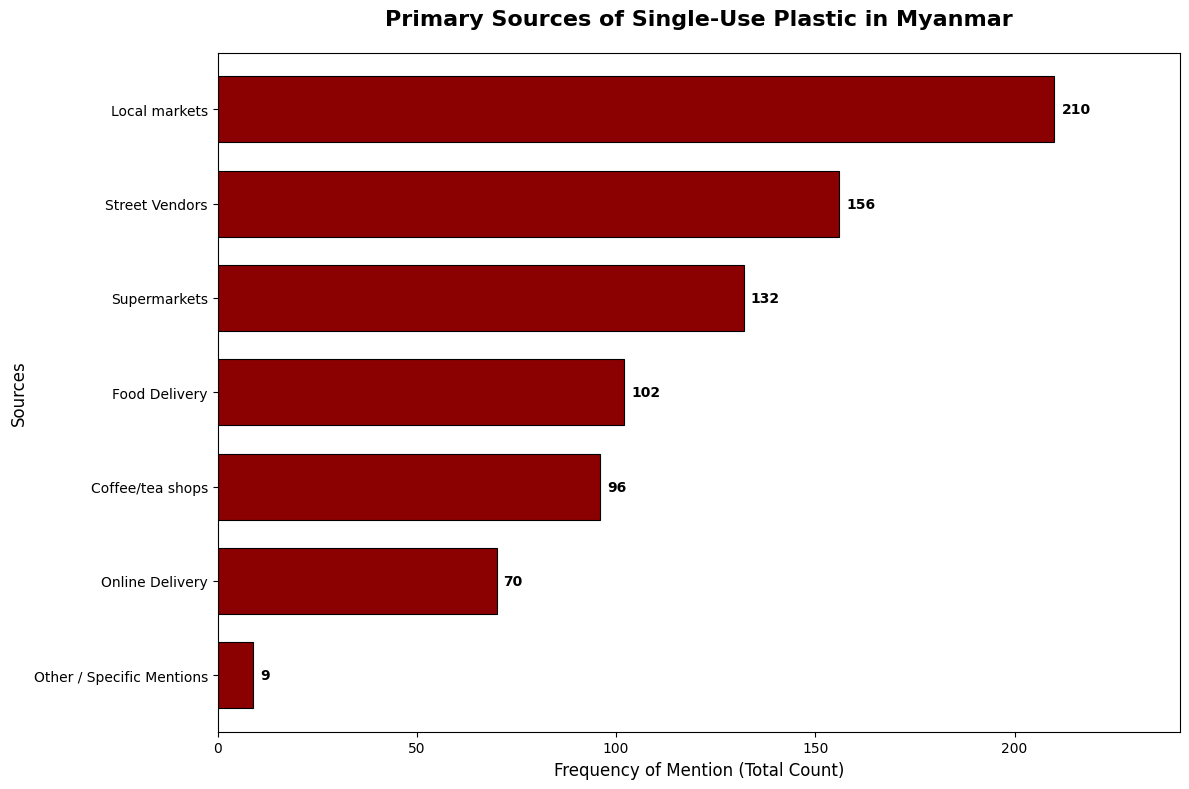

In [23]:
#10.The "Source" of the Problem
#Where does the plastic come from (Q8)?
#Process the multi-choice data
sources = df['Sources'].str.split(',').explode().str.strip()
counts = sources.value_counts()
#Keep anything with more than 5 mentions, group the rest as 'Other'
threshold = 5
mask = counts > threshold
cleaned_counts = counts[mask]
cleaned_counts['Other / Specific Mentions'] = counts[~mask].sum()
plt.figure(figsize=(12, 8))
ax = cleaned_counts.plot(kind='barh', color='darkred', edgecolor='black', linewidth=0.8, width=0.7)
ax.bar_label(ax.containers[0], padding=5, fontsize=10, fontweight='bold')
plt.title('Primary Sources of Single-Use Plastic in Myanmar', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Frequency of Mention (Total Count)', fontsize=12)
plt.ylabel('Sources', fontsize=12)
plt.xlim(0, cleaned_counts.max() * 1.15)
plt.gca().invert_yaxis() #This keeps 'Local Markets' at the top
plt.tight_layout()
plt.show()

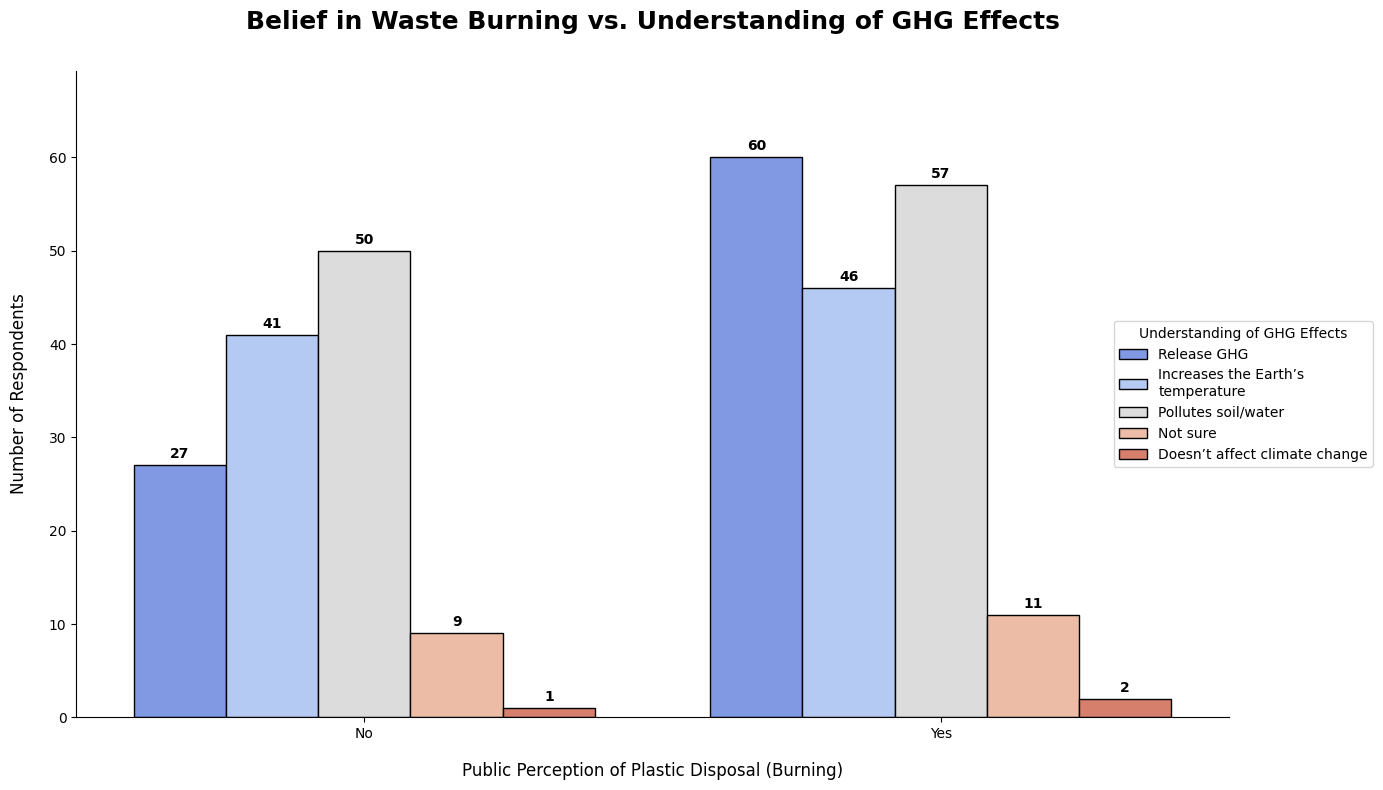

In [70]:
#11.Burning Perception vs. GHG Awareness
#Does seeing burning (Q18) increase awareness of GHG effects (Q22)?
plt.figure(figsize=(14, 8))
ax = sns.countplot(
    data=df, 
    x='Burn_Waste', 
    hue='Climate_Effect', 
    palette='coolwarm', 
    edgecolor='black')
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')
leg = ax.legend(
    title='Understanding of GHG Effects', 
    bbox_to_anchor=(0.9, 0.5), 
    loc='center left', 
    borderaxespad=0
)
for text in leg.get_texts():
    text.set_text(textwrap.fill(text.get_text(), 30))
plt.title('Belief in Waste Burning vs. Understanding of GHG Effects', fontsize=18, fontweight='bold', pad=30)
plt.xlabel('Public Perception of Plastic Disposal (Burning)', fontsize=12, labelpad=15)
plt.ylabel('Number of Respondents', fontsize=12, labelpad=15)
plt.ylim(0, ax.get_ylim()[1] * 1.1)
sns.despine()
plt.tight_layout()
plt.show()

In [71]:
#1.Define data for Weight and Emission_Factor
plastic_info = {
    "Plastic bags": (7, 5.4),               
    "Bottled water": (10, 5.9),             
    "Plastic food containers": (20, 4.8),   
    "Plastic straws": (1, 4.8),             
    "Disposable forks and spoons": (3, 6.2),  
    "Food sachets": (2, 5.6)
}

#2.Input Section
print("--- Myanmar SUP Consumption Tracker (Weekly) ---")
# Collecting counts in a dictionary for easier iteration
counts = {
    "Plastic bags": int(input("How many plastic bags do you use per week? ")),
    "Bottled water": int(input("How many bottled water plastics do you use per week? ")),
    "Plastic food containers": int(input("How many plastic food containers do you use per week? ")),
    "Plastic straws": int(input("How many plastic straws do you use per week? ")),
    "Disposable forks and spoons": int(input("How many disposable forks/spoons do you use per week? ")),
    "Food sachets": int(input("How many food sachets do you use per week? "))
}

#3.Summary and Precise Calculations
total_weekly_grams = 0
total_weekly_co2e = 0
breakdown = []

for item, count in counts.items():
    weight_g, ef = plastic_info[item]
    
    #Calculate mass for category
    item_mass_g = count * weight_g
    item_mass_kg = item_mass_g / 1000
    
    #Calculate CO2e for this category using its specific Emission Factor
    item_co2e = item_mass_kg * ef
    
    total_weekly_grams += item_mass_g
    total_weekly_co2e += item_co2e
    
    #Store for the summary table
    breakdown.append((item, count, item_mass_g, item_co2e))
total_weekly_kg = total_weekly_grams / 1000

#4.Summary of Inputs and Results
print("\n" + "="*60)
print(f"{'WEEKLY CONSUMPTION & EMISSIONS SUMMARY':^60}")
print("="*60)
print(f"{'Item':<25} | {'Count':<6} | {'Mass (g)':<10} | {'CO2e (kg)':<10}")
print("-" * 60)

for item, count, mass, co2 in breakdown:
    print(f"{item:<25} | {count:<6} | {mass:<10} | {co2:.3f}")

print("-" * 60)
print(f"TOTAL WEEKLY MASS:       {total_weekly_grams}g ({total_weekly_kg:.3f} kg)")
print(f"TOTAL WEEKLY CO2e:       {total_weekly_co2e:.3f} kg CO2e")
print("="*60)
print(f"Estimated Yearly Impact:  {total_weekly_co2e * 52:.2f} kg CO2e")
print("="*60)

--- Myanmar SUP Consumption Tracker (Weekly) ---

           WEEKLY CONSUMPTION & EMISSIONS SUMMARY           
Item                      | Count  | Mass (g)   | CO2e (kg) 
------------------------------------------------------------
Plastic bags              | 3      | 21         | 0.113
Bottled water             | 3      | 30         | 0.177
Plastic food containers   | 3      | 60         | 0.288
Plastic straws            | 3      | 3          | 0.014
Disposable forks and spoons | 3      | 9          | 0.056
Food sachets              | 3      | 6          | 0.034
------------------------------------------------------------
TOTAL WEEKLY MASS:       129g (0.129 kg)
TOTAL WEEKLY CO2e:       0.682 kg CO2e
Estimated Yearly Impact:  35.47 kg CO2e
